# Task 1
Підготуйте дані для моделі.
* Використовуйте датасет Heart Disease UCI (або аналогічний CSV з ознаками пацієнтів).
* Розділіть вибірку на train/test у пропорції 80/20 (random_state=42).
* Масштабуйте ознаки через StandardScaler.
* Перевірте баланс класів (низький/високий ризик) і за необхідності застосуйте stratify.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from IPython.display import Markdown as md

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

# Task 2
Побудуйте архітектуру MLP:
* Вхідний шар — кількість нейронів = числу ознак
* Приховані шари:
    - 1-й: 16 нейронів, активація ReLU.
    - 2-й: 8 нейронів, активація ReLU:
        - Вихідний шар: 1 нейрон, активація Sigmoid.
        - Використовуйте torch.nn.Sequential для побудови моделі.

In [3]:
input_dim = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

# Task 3
Навчіть модель:
* Функція втрат — BCELoss.
* Оптимізатор — Adam (lr = 0.001).
* Епохи: 30.
* Виводьте значення втрат і точності (Accuracy) після кожної епохи.
* Після закінчення навчання виведіть підсумкові метрики:

In [7]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()
    
    predictions = (outputs >= 0.5).float()
    acc = accuracy_score(y_train_t.numpy(), predictions.numpy())
    
    train_losses.append(loss.item())
    train_accuracies.append(acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Accuracy: {acc:.4f}")

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    test_loss = criterion(test_outputs, y_test_t).item()
    test_predictions = (test_outputs >= 0.5).float()
    test_acc = accuracy_score(y_test_t.numpy(), test_predictions.numpy())

md("|Metric|Value|\n|-|-|\n|Test Loss|%f|\n|Test Accuracy|%f|\n" % (test_loss, test_acc))

Epoch 1/30 | Loss: 0.6116 | Accuracy: 0.6923
Epoch 2/30 | Loss: 0.6088 | Accuracy: 0.7077
Epoch 3/30 | Loss: 0.6060 | Accuracy: 0.7187
Epoch 4/30 | Loss: 0.6031 | Accuracy: 0.7275
Epoch 5/30 | Loss: 0.6003 | Accuracy: 0.7319
Epoch 6/30 | Loss: 0.5973 | Accuracy: 0.7385
Epoch 7/30 | Loss: 0.5944 | Accuracy: 0.7473
Epoch 8/30 | Loss: 0.5914 | Accuracy: 0.7582
Epoch 9/30 | Loss: 0.5884 | Accuracy: 0.7648
Epoch 10/30 | Loss: 0.5854 | Accuracy: 0.7758
Epoch 11/30 | Loss: 0.5823 | Accuracy: 0.7846
Epoch 12/30 | Loss: 0.5792 | Accuracy: 0.7890
Epoch 13/30 | Loss: 0.5761 | Accuracy: 0.7956
Epoch 14/30 | Loss: 0.5729 | Accuracy: 0.8022
Epoch 15/30 | Loss: 0.5696 | Accuracy: 0.8132
Epoch 16/30 | Loss: 0.5664 | Accuracy: 0.8154
Epoch 17/30 | Loss: 0.5630 | Accuracy: 0.8198
Epoch 18/30 | Loss: 0.5596 | Accuracy: 0.8220
Epoch 19/30 | Loss: 0.5562 | Accuracy: 0.8286
Epoch 20/30 | Loss: 0.5527 | Accuracy: 0.8352
Epoch 21/30 | Loss: 0.5492 | Accuracy: 0.8462
Epoch 22/30 | Loss: 0.5456 | Accuracy: 0.85

|Metric|Value|
|-|-|
|Test Loss|0.518005|
|Test Accuracy|0.903509|


# Task 4
* Візуалізуйте результати:
    - Побудуйте два графіки.
    - Втрати (Loss) за епохами.
    - Точність (Accuracy) за епохами:
        - Підпишіть осі, додайте легенду.
        - Збережіть графіки під іменами loss_healthrisk_mlp.png і accuracy_healthrisk_mlp.png.
        - Зробіть короткий висновок: чи покращується якість у міру навчання?



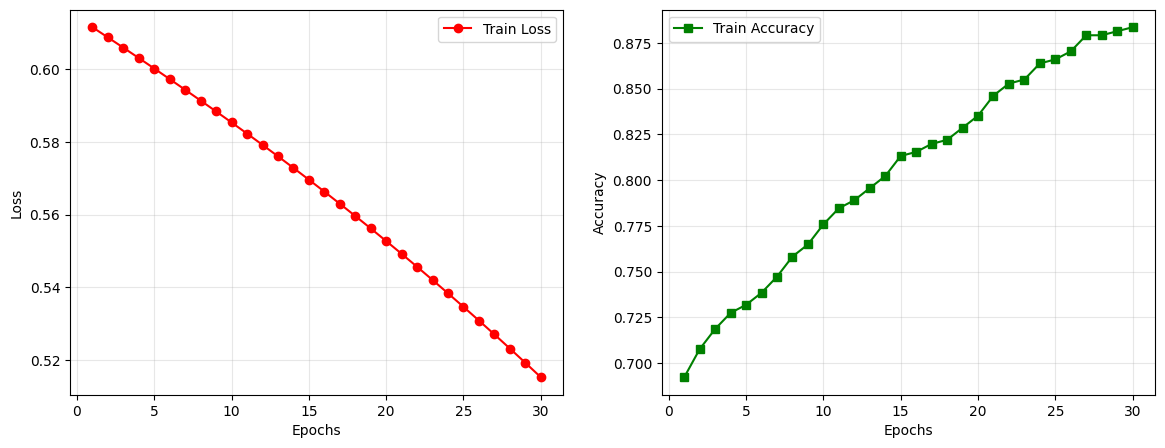

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(range(1, epochs+1), train_losses, color='red', marker='o', label='Train Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True, alpha=0.3)
fig.savefig('loss_healthrisk_mlp.png')

axs[1].plot(range(1, epochs+1), train_accuracies, color='green', marker='s', label='Train Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True, alpha=0.3)
fig.savefig('accuracy_healthrisk_mlp.png')

plt.show()